## What is the most optimal skill to learn for Data Analysts in Spain in 2023?

### Methodology

  1. Group skills to determine median salary and likelihood of being in posting
  2. Visualize median salary vs percent skill demand
  3. (Optional) Determine if certain technologies are more prevalent

In [1]:
# Importing Libriaries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

# Loading Data
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
df_DA_SPA = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'Spain')].copy()

In [3]:
df_DA_SPA = df_DA_SPA.dropna(subset=['salary_year_avg'])

df_DA_SPA_exploded = df_DA_SPA.explode('job_skills')

df_DA_SPA_exploded[['salary_year_avg', 'job_skills']].head(5)



,salary_year_avg,job_skills
17710,51014.0,None
32177,111175.0,sql
32177,111175.0,python
32177,111175.0,r
32177,111175.0,databricks


In [ ]:
df_DA_skills = df_DA_SPA_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)

df_DA_skills = df_DA_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})   

DA_job_count = len(df_DA_SPA)

df_DA_skills['skill_percent'] = df_DA_skills['skill_count'] / DA_job_count * 100

skill_percent = 8

df_DA_skills_high_demand = df_DA_skills[df_DA_skills['skill_percent'] > skill_percent]

df_DA_skills_high_demand


,skill_count,median_salary,skill_percent
job_skills,,,
sql,17,89100.0,56.666667
python,14,98500.0,46.666667
tableau,9,98500.0,30.000000
excel,5,72900.0,16.666667
power bi,4,73352.0,13.333333
pandas,4,108087.5,13.333333
looker,4,111175.0,13.333333
airflow,3,98500.0,10.000000
jupyter,3,105000.0,10.000000


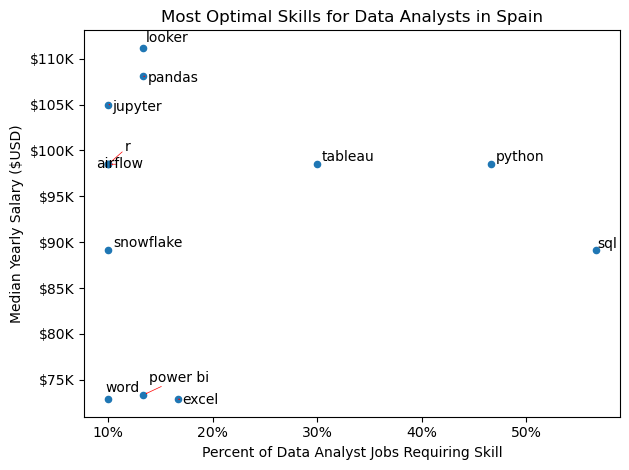

In [5]:
from adjustText import adjust_text
from matplotlib.ticker import PercentFormatter

df_DA_skills_high_demand.plot(kind='scatter', x='skill_percent', y='median_salary')

texts = []

for i, txt in enumerate(df_DA_skills_high_demand.index):
    texts.append(plt.text(df_DA_skills_high_demand['skill_percent'].iloc[i], df_DA_skills_high_demand['median_salary'].iloc[i], txt))

adjust_text(texts, arrowprops=dict(arrowstyle="->", color='r', lw=0.5))

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

plt.xlabel('Percent of Data Analyst Jobs Requiring Skill')
plt.ylabel('Median Yearly Salary ($USD)')
plt.title('Most Optimal Skills for Data Analysts in Spain')
plt.tight_layout()

plt.show()

In [6]:
df['job_type_skills'].head(10)

0                                                 None
1    {'analyst_tools': ['power bi', 'tableau'], 'pr...
2    {'analyst_tools': ['dax'], 'cloud': ['azure'],...
3    {'cloud': ['aws'], 'libraries': ['tensorflow',...
4    {'cloud': ['oracle', 'aws'], 'other': ['ansibl...
5    {'cloud': ['gcp'], 'programming': ['python', '...
6    {'cloud': ['gcp', 'bigquery'], 'databases': ['...
7    {'cloud': ['gcp', 'azure', 'aws', 'bigquery', ...
8    {'analyst_tools': ['excel', 'powerpoint', 'pow...
9    {'analyst_tools': ['excel'], 'cloud': ['azure'...
Name: job_type_skills, dtype: object

In [7]:
df_technology = df['job_type_skills'].copy()

# remove duplicates
df_technology = df_technology.drop_duplicates()

# remove NaN values
df_technology = df_technology.dropna()

# combine all dictionaries into one
technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row) # convert string to dictionary
    for key, value in row_dict.items():
        if key in technology_dict: # if key already exists, add the value
            technology_dict[key] += value
        else:                       # if key does not exist, create it
            technology_dict[key] = value

# remove duplicates by converting values to set and back to list
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

technology_dict



{'analyst_tools': ['ssrs',
  'tableau',
  'outlook',
  'excel',
  'msaccess',
  'cognos',
  'word',
  'sap',
  'alteryx',
  'visio',
  'qlik',
  'looker',
  'spreadsheet',
  'splunk',
  'powerpoint',
  'powerbi',
  'nuix',
  'sheets',
  'datarobot',
  'ssis',
  'sharepoint',
  'spss',
  'dax',
  'microstrategy',
  'esquisse',
  'power bi',
  'ms access',
  'sas'],
 'programming': ['elixir',
  'cobol',
  'php',
  'bash',
  'ocaml',
  'mongo',
  'sass',
  'visual basic',
  'scala',
  'delphi',
  'vba',
  'perl',
  'ruby',
  'r',
  'javascript',
  'golang',
  'c++',
  'groovy',
  'nosql',
  'lisp',
  'erlang',
  'crystal',
  'swift',
  'fortran',
  'java',
  'matlab',
  'sql',
  'f#',
  'assembly',
  'python',
  'apl',
  'html',
  'objective-c',
  'haskell',
  'powershell',
  'kotlin',
  'lua',
  'mongodb',
  'vb.net',
  'pascal',
  'dart',
  'clojure',
  'visualbasic',
  'no-sql',
  'shell',
  'c',
  'julia',
  'go',
  'typescript',
  't-sql',
  'rust',
  'css',
  'c#',
  'sas',
  'solid

In [9]:
df_technology= pd.DataFrame(list(technology_dict.items()), columns=['Technology', 'Skills'])

df_technology = df_technology.explode('Skills')

df_technology

,Technology,Skills
0,analyst_tools,ssrs
0,analyst_tools,tableau
0,analyst_tools,outlook
0,analyst_tools,excel
0,analyst_tools,msaccess
...,...,...
9,sync,symphony
9,sync,ringcentral
9,sync,zoom
9,sync,slack


In [12]:
df_plot = df_DA_skills_high_demand.merge(df_technology, left_on='job_skills', right_on='Skills')

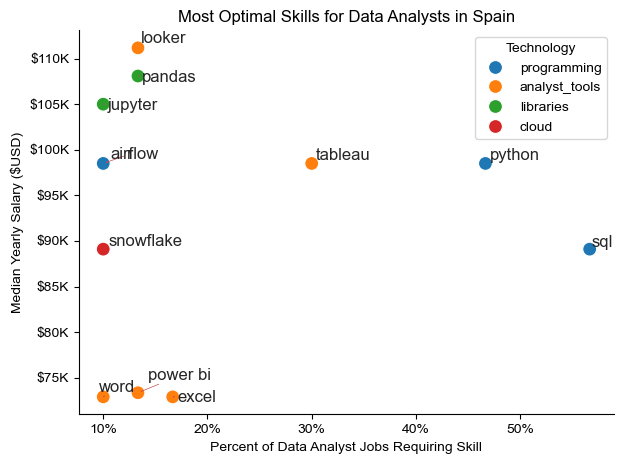

In [16]:
from adjustText import adjust_text
from matplotlib.ticker import PercentFormatter

# df_plot.plot(kind='scatter', x='skill_percent', y='median_salary')

sns.scatterplot(
    data=df_plot,
    x='skill_percent',
    y='median_salary',
    hue='Technology',
    s=100,
    palette='tab10'
)

sns.despine()
sns.set_theme(style="ticks")


texts = []

for i, txt in enumerate(df_DA_skills_high_demand.index):
    texts.append(plt.text(df_DA_skills_high_demand['skill_percent'].iloc[i], df_plot['median_salary'].iloc[i], txt))

adjust_text(texts, arrowprops=dict(arrowstyle="->", color='r', lw=0.5))

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

plt.xlabel('Percent of Data Analyst Jobs Requiring Skill')
plt.ylabel('Median Yearly Salary ($USD)')
plt.title('Most Optimal Skills for Data Analysts in Spain')
plt.tight_layout()

plt.show()